In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading & Initial Inspection

In [25]:
pd.set_option('display.max_columns', None)

In [26]:
# Load data

training = pd.read_csv("../data/row/train.csv")
testing = pd.read_csv("../data//row/test.csv")

display(training.head())
display(testing.head())
display(training.info())
display(testing.info())

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 48.5 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 7.1 MB


None

## 2. Data Cleaning & Preprocessing

In [27]:
# Concat
data = pd.concat([training, testing], axis= 0, ignore_index= True)
data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  str    
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  str    
 8   Contract Length    505206 non-null  str    
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), str(3)
memory usage: 55.5 MB


**Data Overview:**
* **Data Merging:** Combined the training and testing datasets into a single DataFrame to apply cleaning and preprocessing steps uniformly.
* **Dataset Size:** The combined dataset contains a total of 505,207 rows and 12 columns.
* **Missing Values:** There is no missing values.

In [29]:
data = data.drop(columns= 'CustomerID')
data.dropna(inplace= True)

In [30]:
data.isna().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [31]:
data.duplicated().sum()

np.int64(0)

**Initial Data Cleaning:**
* **Identifier Removal:** Dropped the `CustomerID` column, as it is a unique identifier and holds no predictive value for the machine learning model.
* **Handling Missing Values:** Dropped the single null row using `dropna()`, as its removal has negligible impact on a dataset of this scale.
* **Duplicates Check:** Verified that there are no duplicate rows in the dataset. The data is now clean and ready for Exploratory Data Analysis (EDA).

## 3. Data Understanding

In [32]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,505206.0,39.704172,12.670577,18.0,29.0,40.0,49.0,65.0
Tenure,505206.0,31.350435,17.237482,1.0,16.0,32.0,46.0,60.0
Usage Frequency,505206.0,15.714825,8.619323,1.0,8.0,16.0,23.0,30.0
Support Calls,505206.0,3.833317,3.133603,0.0,1.0,3.0,6.0,10.0
Payment Delay,505206.0,13.496843,8.451187,0.0,6.0,13.0,20.0,30.0
Total Spend,505206.0,620.072766,245.319256,100.0,446.0,648.9,824.0,1000.0
Last Interaction,505206.0,14.610581,8.608286,1.0,7.0,14.0,22.0,30.0
Churn,505206.0,0.555203,0.496944,0.0,0.0,1.0,1.0,1.0


In [33]:
data[data.select_dtypes('str').columns].describe().T

,count,unique,top,freq
Gender,505206,2,Male,280273
Subscription Type,505206,3,Standard,170630
Contract Length,505206,3,Annual,198608


**Statistical Summary & Data Integrity Check:**
* **Numerical Features:** The descriptive statistics indicate that the numerical columns are generally well-distributed. The ranges between the minimum, maximum, and quartile values appear logical, suggesting an absence of severe or extreme outliers. This observation will be further verified visually in the subsequent steps.
* **Categorical Features:** Inspecting the categorical summary and the unique values confirms the integrity of the text data. There are no data entry errors, misspellings, or unexpected categories. For instance, the 'Gender' column strictly contains two valid inputs, and the rest of the categorical features have the expected distinct values.

In [34]:
cat_cols = data.select_dtypes('str').columns

for col in cat_cols:
    display(f"{col} : {list(data[col].unique())}")

"Gender : ['Female', 'Male']"

"Subscription Type : ['Standard', 'Basic', 'Premium']"

"Contract Length : ['Annual', 'Monthly', 'Quarterly']"

In [35]:
data['Churn'].value_counts()

Churn
1.0    280492
0.0    224714
Name: count, dtype: int64

**Target Variable Distribution (Class Imbalance Check):**
* The distribution between churned and non-churned customers is 280,000 to 224,000. 
* The difference is not extreme enough to severely bias the machine learning model, meaning advanced resampling techniques (like SMOTE or heavy undersampling) are likely unnecessary at this stage.

In [36]:
data.select_dtypes('number').sum() < 0

Age                 False
Tenure              False
Usage Frequency     False
Support Calls       False
Payment Delay       False
Total Spend         False
Last Interaction    False
Churn               False
dtype: bool

**Logical Data Integrity Check:**
* All numerical features are strictly positive or zero, confirming the logical soundness of the data. This guarantees that there are no "hidden" logical outliers that might bypass standard visual outlier detection methods.

## 4. Univariate Analysis

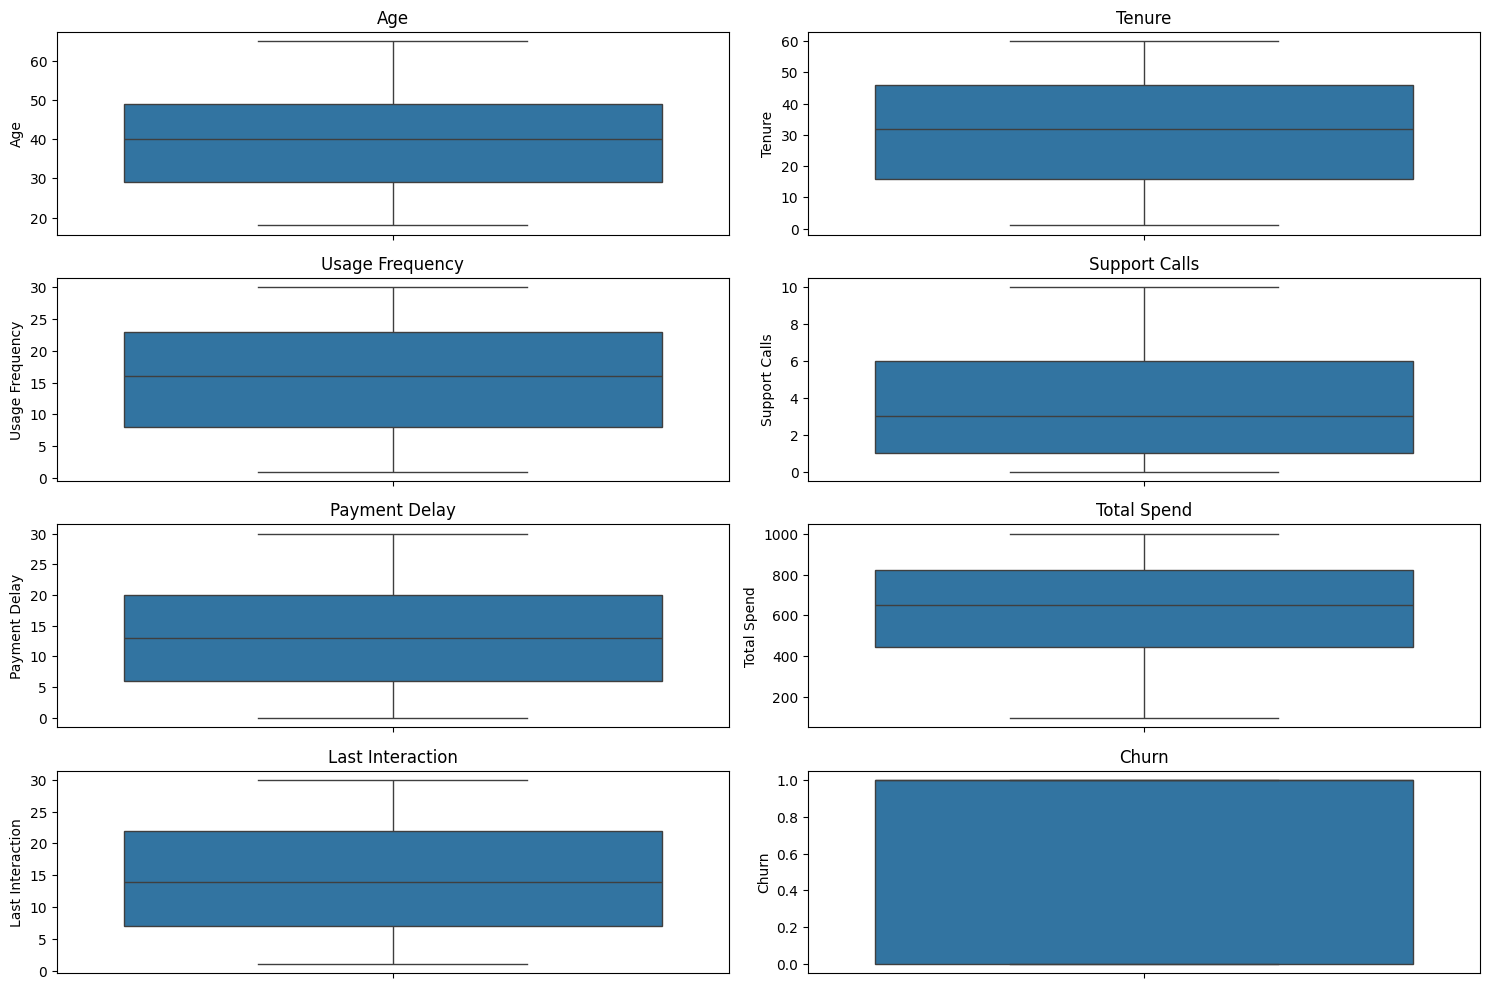

In [37]:
num_cols = data.select_dtypes('number').columns

plt.figure(figsize= (15, 10))
for index, col in enumerate(num_cols, 1):
    plt.subplot(4,2, index)
    sns.boxplot(data[col])
    plt.title(f'{col}')
    
plt.tight_layout()
plt.show()

**Outlier Detection**
* **Visual Inspection:** Boxplots were utilized across all numerical columns to visually identify any extreme values or anomalies.
* **Observation:** The visualizations align with the initial statistical summary, confirming a complete absence of outliers within the continuous numerical features. 
* **Conclusion:** No outlier treatment or capping techniques are required for the preprocessing pipeline.

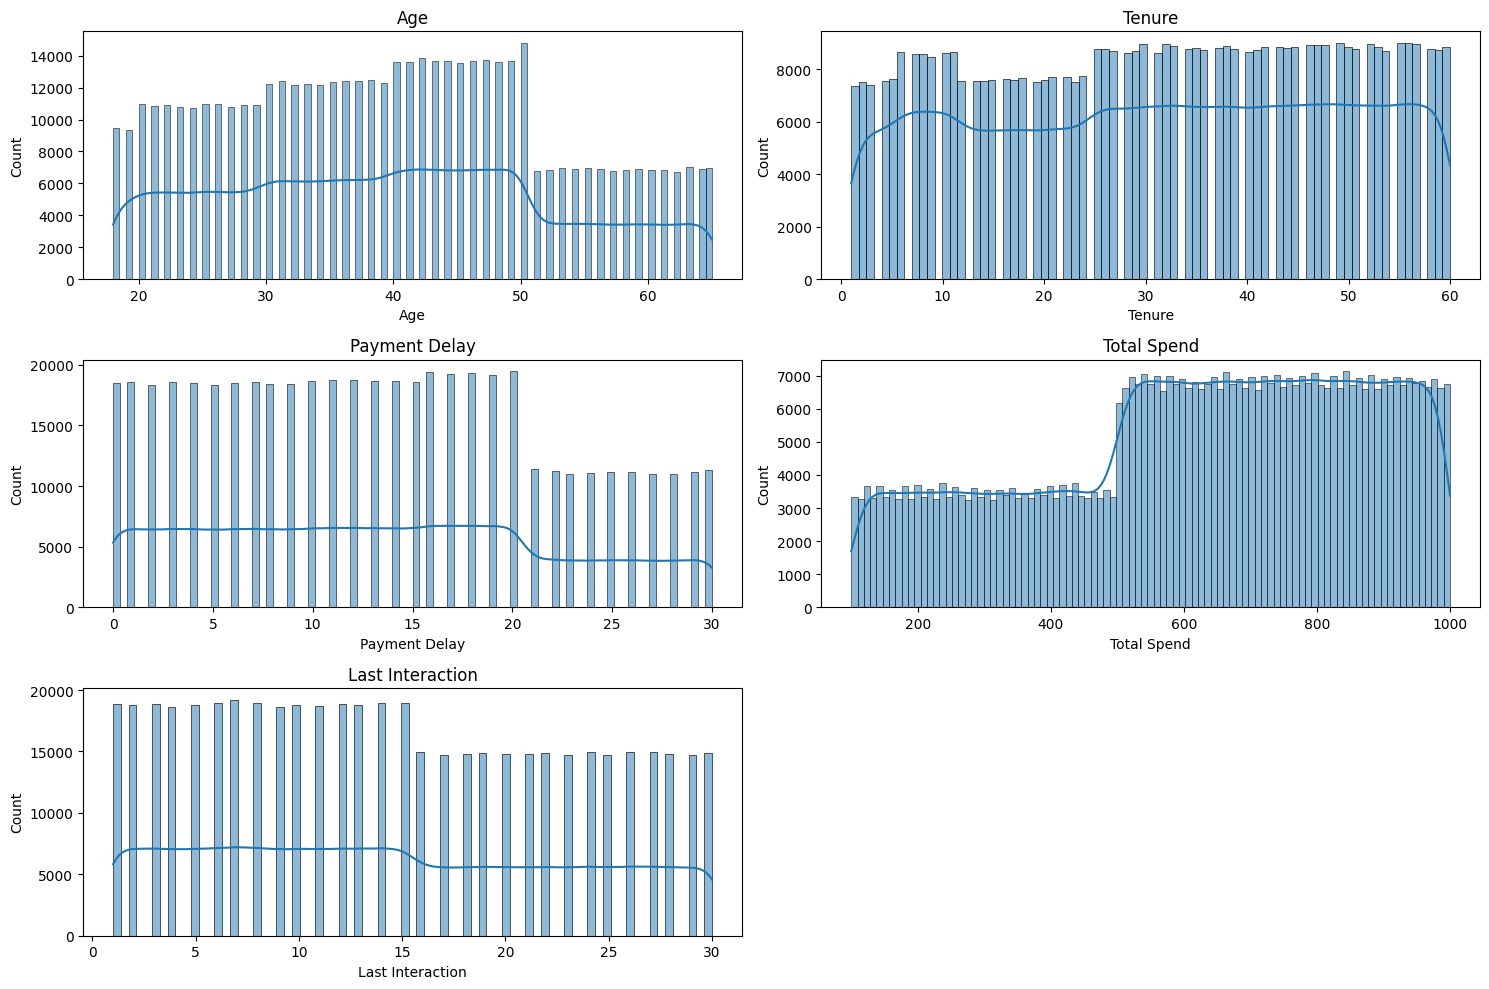

In [38]:
cols = ['Age', 'Tenure', 'Payment Delay',
       'Total Spend', 'Last Interaction']

plt.figure(figsize= (15, 10))
for index, col in enumerate(cols, 1):
    plt.subplot(3, 2, index)
    sns.histplot(data[col], kde= True)
    plt.title(col)
    
plt.tight_layout()
plt.show()

**Numerical Feature Distributions**
* **Age:** The majority of customers fall between 18 and 50 years old, with the highest concentration in the 40-50 demographic. There is a distinct, sharp drop in customer frequency immediately after age 50.
* **Tenure:** The distribution is relatively uniform, though there is a slight decrease in the frequency of customers with a tenure between 10 and 25 months.
* **Payment Delay:** High frequency is observed for delays between 0 and 20 days, followed by a sudden and significant drop for delays exceeding 20 days.
* **Total Spend:** Exhibits a clear step-up pattern. The frequency of customers spending between 100 and 500 is notably lower, but it sharply increases and remains high for spending amounts between 500 and 1,000.
* **Last Interaction:** Shows a high and stable frequency for the first 15 days, immediately followed by a sharp decline in the 15 to 30 days range.
* **Key Takeaway:** The shifts patterns observed  (Age 50, Spend 500, Payment Delay 20, Last Interaction 15) suggest data generation rules, and none of these features follow a normal distribution.

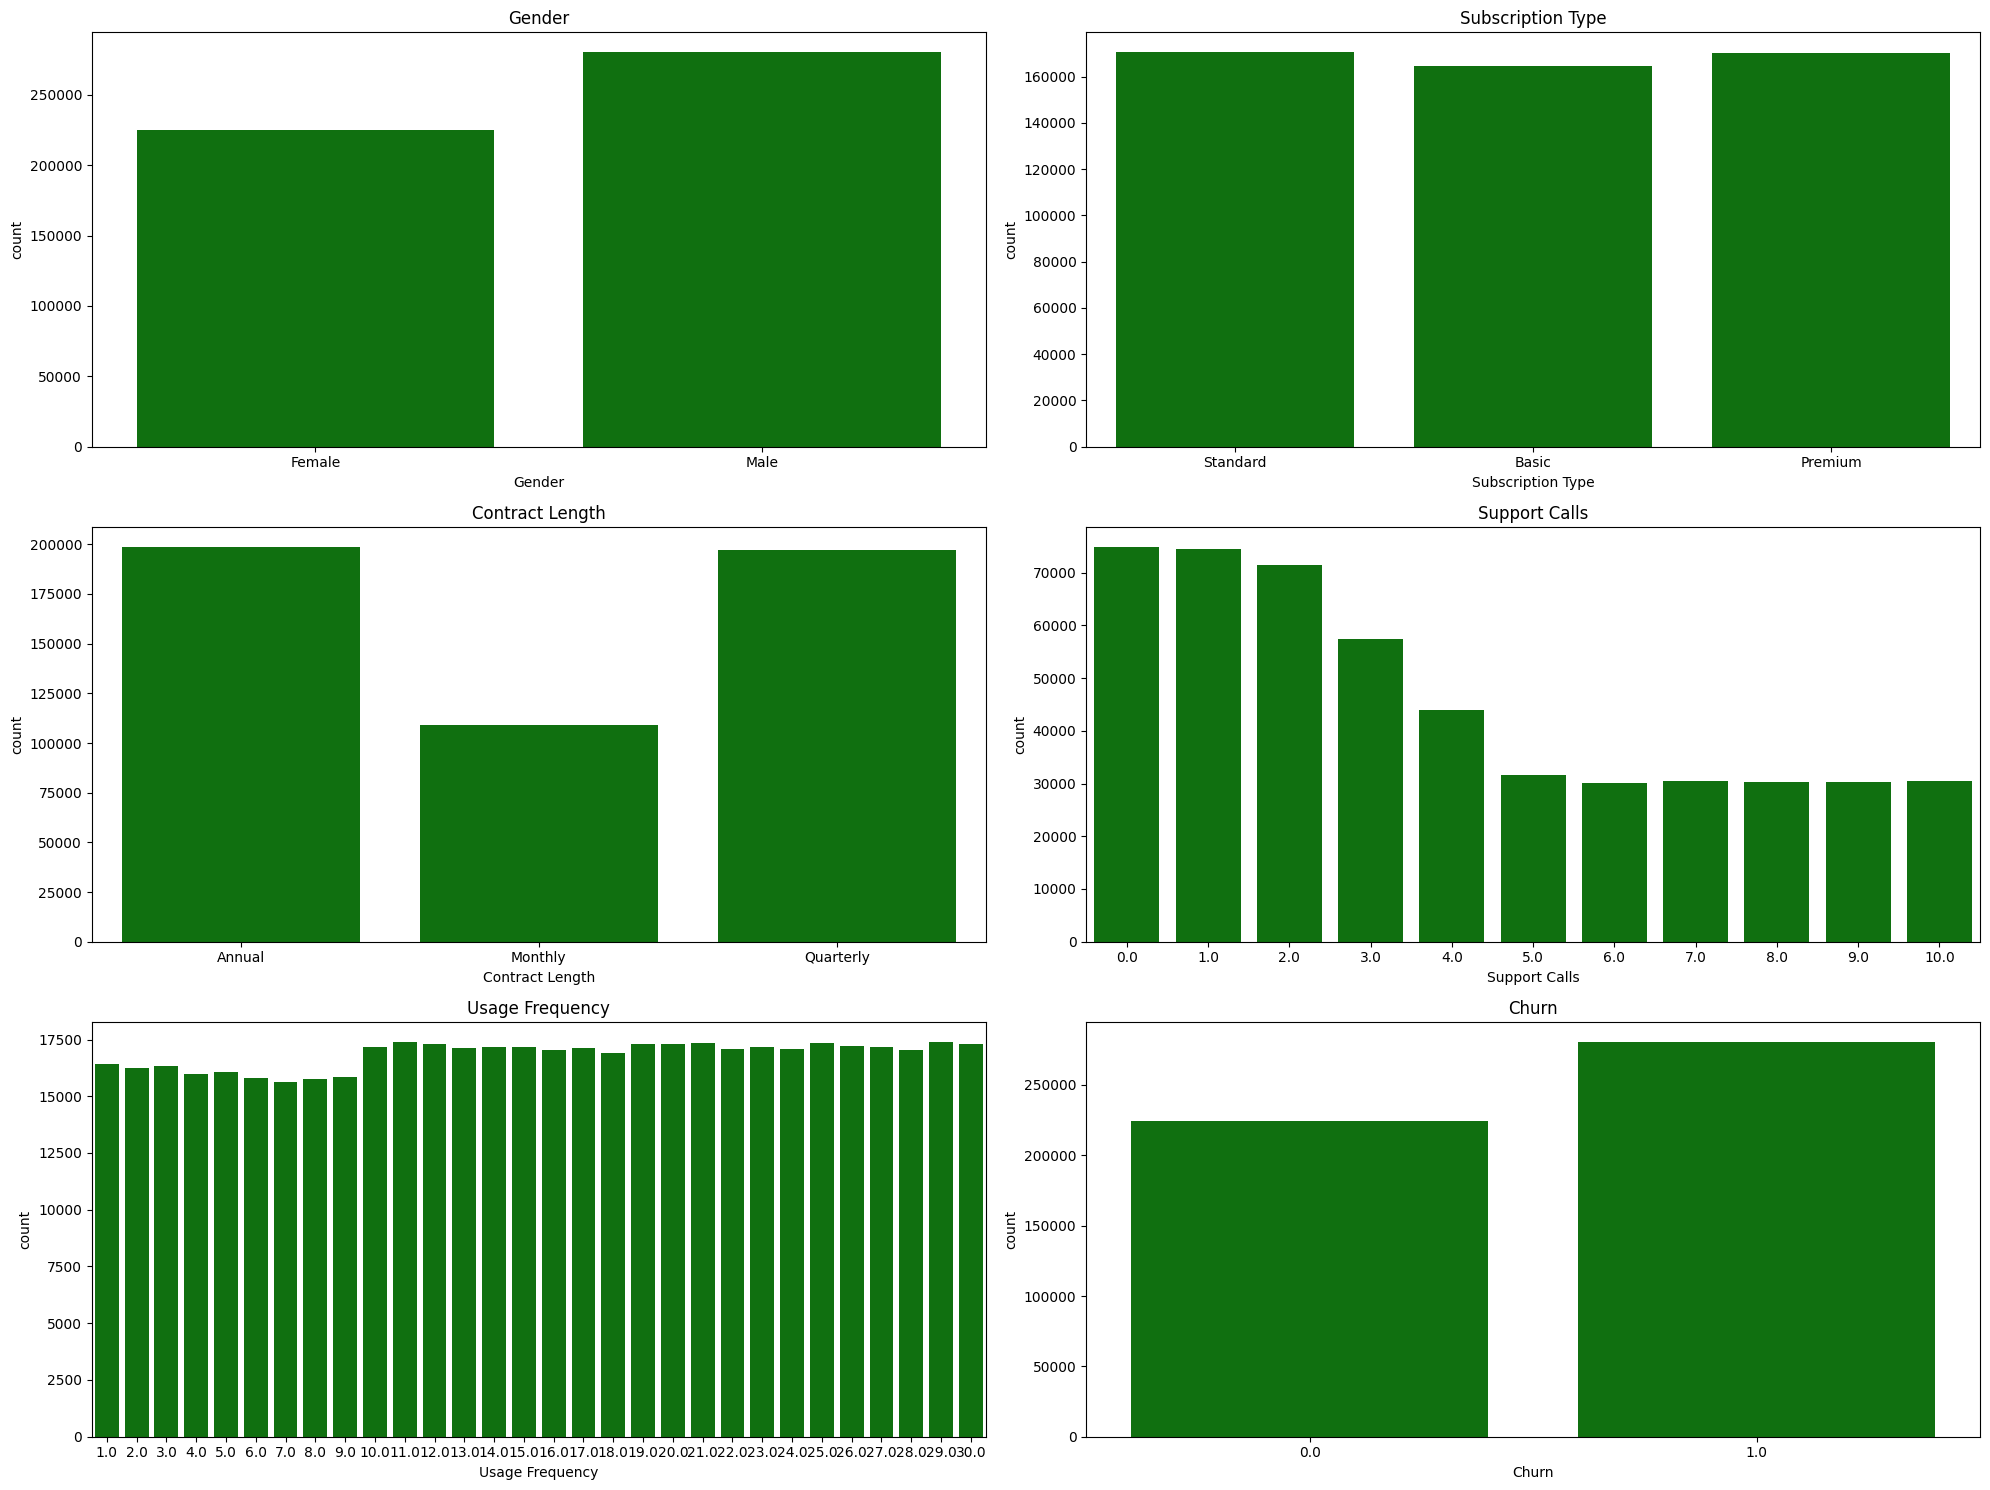

In [40]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length', 'Support Calls', 'Usage Frequency', 'Churn']

plt.figure(figsize= (20, 15))
for index, col in enumerate(cat_cols, 1):
    plt.subplot(3,2, index)
    sns.countplot(data= data, x= col, color= 'g')
    plt.title(col)
    
plt.tight_layout()
plt.show()

**Categorical Feature Distributions**
* **Gender:** The dataset contains slightly more male customers than female customers.
* **Subscription Type:** The distribution is nearly uniform across all three tiers. However, 'Basic' is marginally the lowest, which contradicts typical real-world business scenarios where lower-tier subscriptions usually hold the majority share.
* **Contract Length:** There is an unnatural, near-equal distribution across Monthly, Quarterly, and Annual contracts. In reality, Monthly contracts typically dominate the customer base.
* **Support Calls:** While there is a logical decrease in frequency after 4 calls, the distribution flatlines entirely from 5 to 10 calls. This rigid plateau is highly irregular for human behavior.
* **Usage Frequency:** Exhibits a completely uniform distribution, which is virtually impossible in organic user data.
* **Target Variable (Churn):** The number of churned customers (1) exceeds the number of retained customers (0). A churn rate greater than 50% is a critical business anomaly and unsustainable for a real company. 
* **Key Takeaway & Data Integrity Conclusion:** The uniform distributions across subscriptions and usage, combined with the illogical $>50\%$ churn rate, serve as definitive proof that this dataset is synthetic or has been heavily modified (e.g., artificially oversampled). This insight confirms that the slight class imbalance will not negatively impact model training, but any extracted business insights must be interpreted within the context of synthetic data.

## 5. Bivariate Analysis (Feature vs Churn)

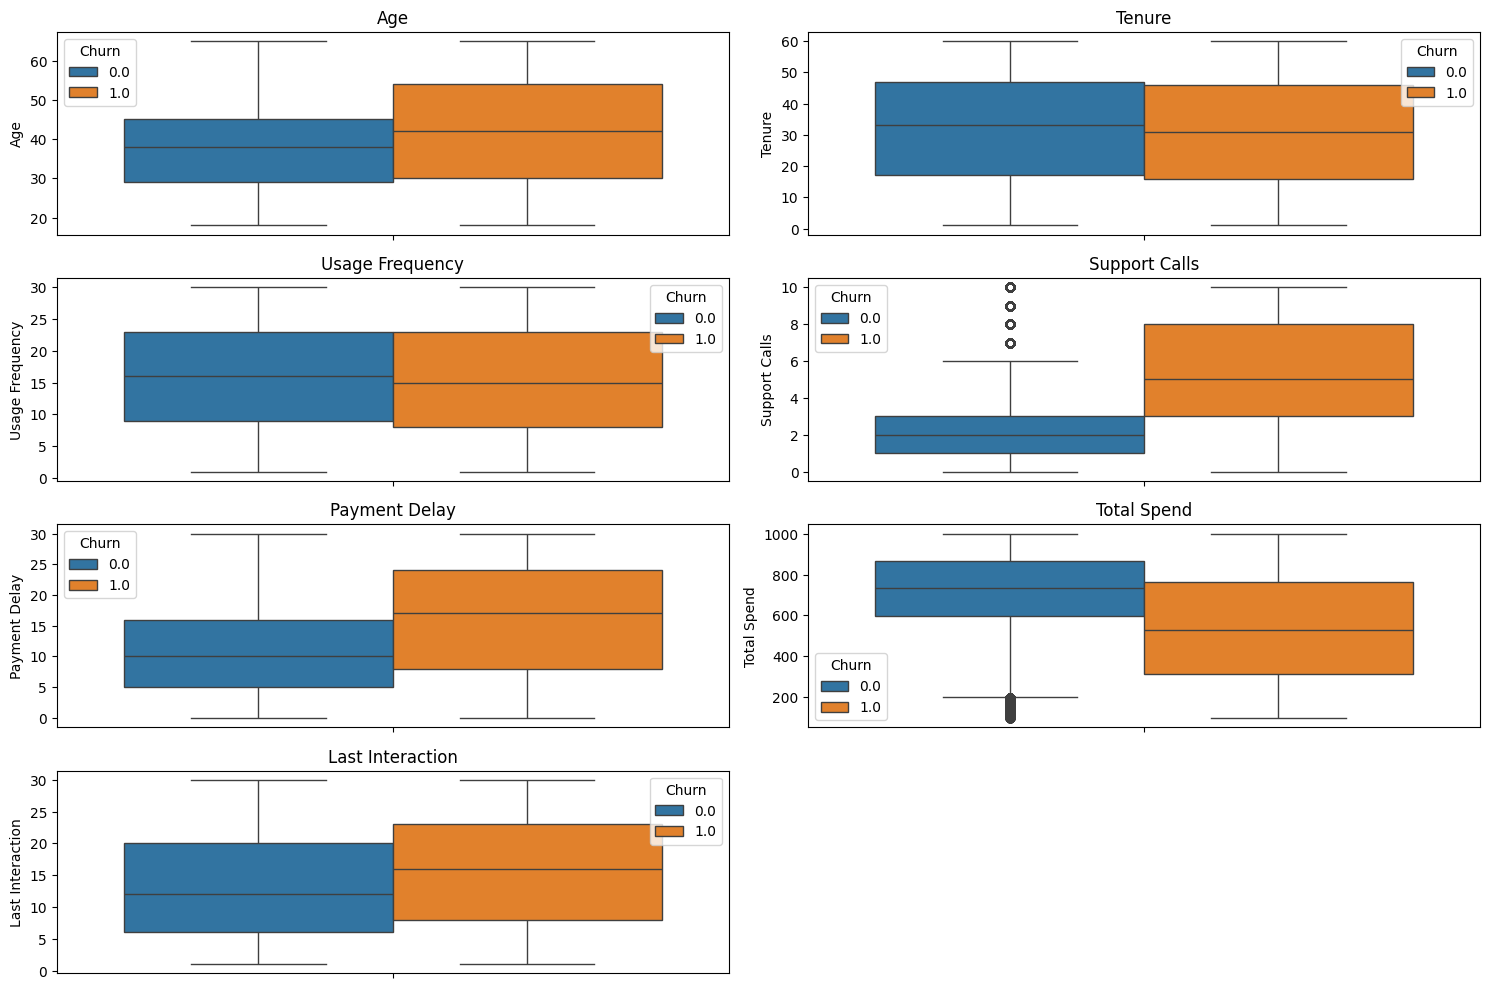

In [41]:
num_cols = data.select_dtypes('number').columns[:-1]

plt.figure(figsize= (15, 10))
for index, col in enumerate(num_cols, 1):
    plt.subplot(4,2, index)
    sns.boxplot(data= data, y= col, hue= 'Churn')
    plt.title(f'{col}')
    
plt.tight_layout()
plt.show()

**Numerical Features vs. Target Variable (Boxplots)**
* **Age:** The interquartile ranges are largely overlapping, but the 75th percentile (Q3) for churned customers is slightly higher than for non-churned customers. This indicates a marginal tendency where older customers might have a higher likelihood of churning.
* **Support Calls:** This feature presents the most distinct variation. Churned customers generally make a significantly higher number of support calls. Notably, there are statistical outliers within the non-churned group—customers who made an unusually high number of calls (6 to 10) but still retained their subscriptions.
* **Total Spend:** Non-churned customers typically demonstrate a higher minimum spending threshold. The outliers present at the bottom of the non-churned boxplot represent a small anomaly of customers with very low total spend who did not churn.
* **Tenure, Usage Frequency, Payment Delay, & Last Interaction:** These features exhibit nearly identical medians and interquartile ranges across both classes. This lack of distinct separation suggests that, individually, these features might not be strong linear discriminators for churn, though they may still contribute to a multi-dimensional predictive model.

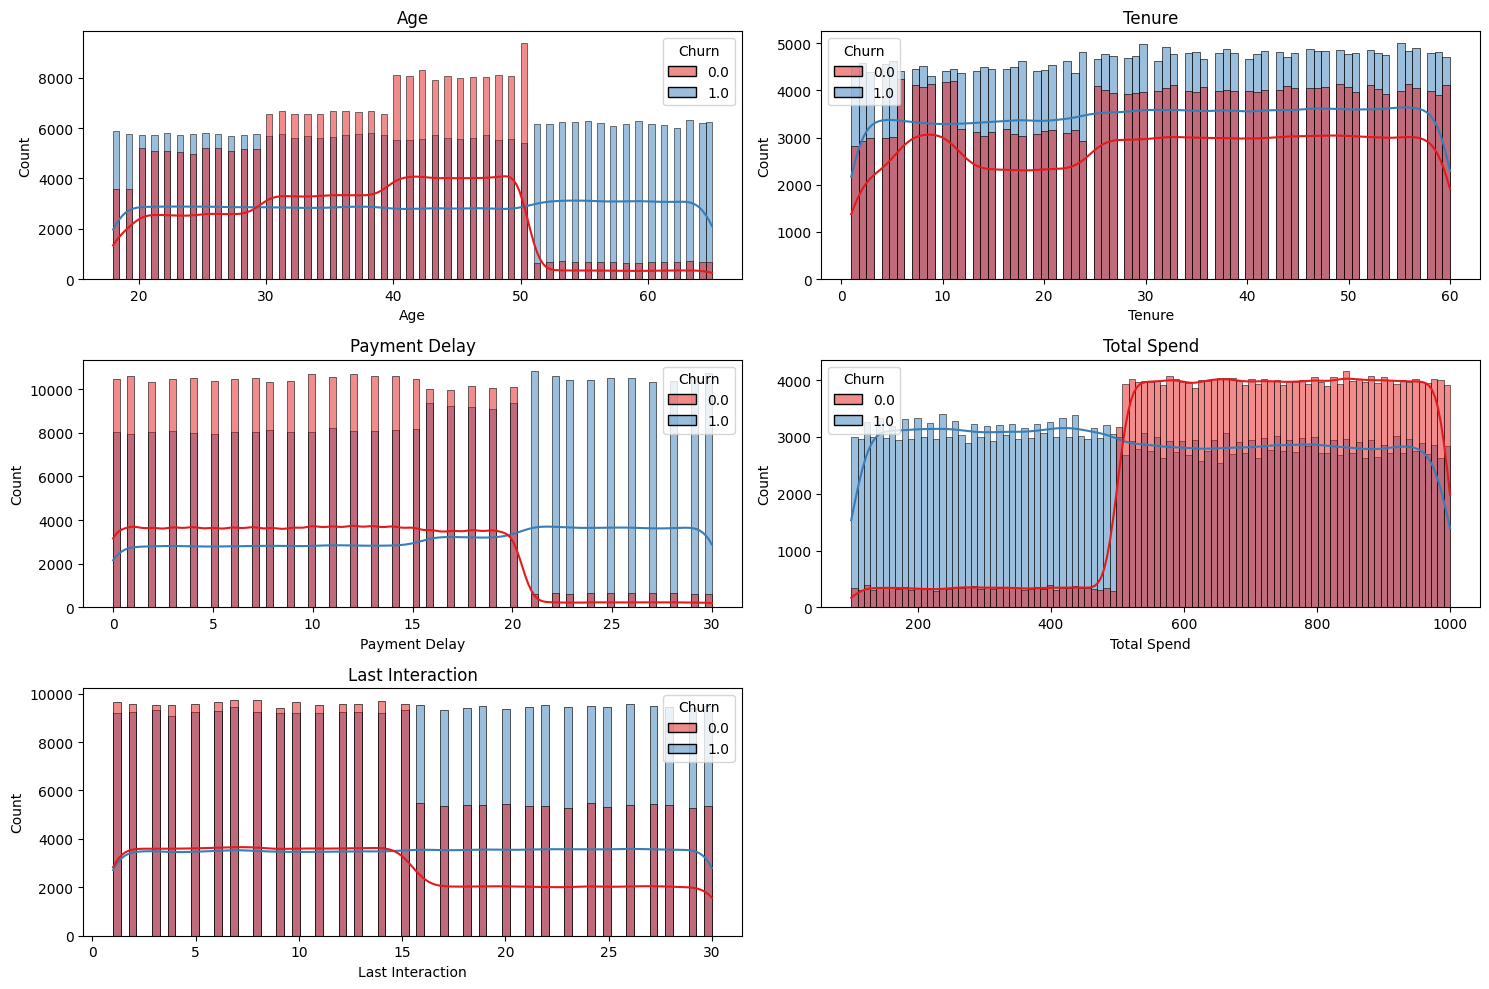

In [42]:
cols = ['Age', 'Tenure', 'Payment Delay',
       'Total Spend', 'Last Interaction']

plt.figure(figsize= (15, 10))
for index, col in enumerate(cols, 1):
    plt.subplot(3, 2, index)
    sns.histplot(data= data, x= col, hue= 'Churn', kde= True, palette= 'Set1', color= (0.99, 0.8, 0.8))
    plt.title(col)
    
plt.tight_layout()
plt.show()

**Feature Distributions vs. Churn (Relative Rate Analysis)**

* **Crucial Analytical Context:** To accurately interpret these distributions, the absolute churn counts (blue) must be cross-referenced with the baseline population distributions observed in the univariate analysis. A flat churn count across a feature does not imply a uniform churn rate if the underlying base population varies.

* **Age:** * **Observation:** The absolute number of churned customers remains completely flat across all ages. However, the univariate analysis showed that the customer base drops significantly between ages 50 and 60.
  * **Insight:** Because the 50-60 age group has a much smaller base population but generates the same absolute volume of churn as the larger 20-50 age group, the actual **churn rate** for customers aged 50-60 is drastically higher. The non-churned distribution perfectly mirrors the baseline population, further confirming that survival drops severely after age 50.

* **Total Spend:** * **Observation:** Similar to Age, the absolute churn count is flat across all spending levels. Yet, the baseline population for the 0-500 spend tier is noticeably lower than the 500-1000 tier. 
  * **Insight:** The proportional churn rate is significantly higher for customers spending under 500. Conversely, the vast majority of retained (non-churned) customers are heavily concentrated in the higher spending tier (>500), which aligns with logical business retention patterns.

* **Last Interaction:** * **Observation:** The churn volume is equal across the 0-15 days and 15-30 days ranges. However, the baseline population is heavily skewed toward the 0-15 days range.
  * **Insight:** Customers whose last interaction exceeds 15 days have a disproportionately higher churn probability. The non-churned segment is almost entirely concentrated in the recent interaction window (0-15 days).

* **Payment Delay:** * **Observation:** This feature exhibits clear logical separation without the need for baseline adjustment. Non-churned customers are tightly clustered in the 0-20 days delay range.
  * **Insight:** Churn probability spikes aggressively for customers who delay payments between 20 and 30 days.

* **Tenure:** * **Observation:** While churn volume is generally higher across the board (reflecting the overall dataset class imbalance), there is a distinct dip in non-churned customers within the 10 to 30-month tenure window.
  * **Insight:** Customers within this specific mid-tenure window exhibit a higher relative likelihood of leaving compared to newer or highly tenured customers.

* **Key Takeaway:** By analyzing relative proportions rather than just raw counts, distinct behavioral thresholds emerge (Age > 50, Spend < 500, Last Interaction > 15, Payment Delay > 20). These precise thresholds indicate strong predictive signals that a Machine Learning classification model will leverage to determine decision boundaries.

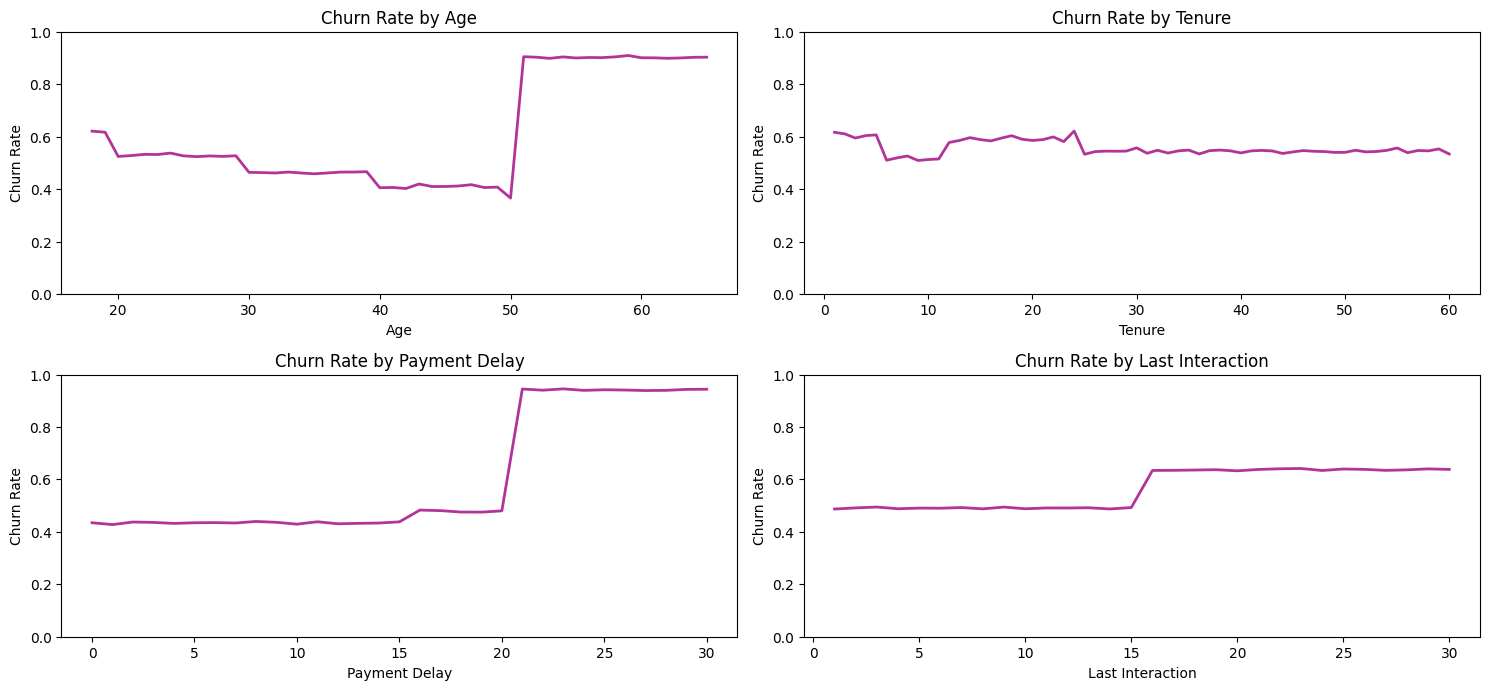

In [43]:
cols = ['Age', 'Tenure', 'Payment Delay', 'Last Interaction']

plt.figure(figsize=(15, 10))

for index, col in enumerate(cols, 1):
    churn_rate = data.groupby(col)['Churn'].mean()
    
    plt.subplot(3, 2, index)
    plt.plot(churn_rate.index, churn_rate.values, color=(0.7, 0.2, 0.6), linewidth=2)
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Churn Rate')
    plt.ylim(0, 1)              # to reduce the zigzag in the line drawn (but change just the zoom of the plot)
    
plt.tight_layout()
plt.show()



**Churn Rate by Feature**

**Overview**
* To validate the relative proportion insights deduced from the absolute distributions, the explicit Churn Rate (Churn Probability) was calculated and plotted for binned numerical features. 

**Validated Insights**
* **Age:** Confirms a sharp, step-wise increase in churn rate for customers over the age of 50.
* **Payment Delay:** Shows a dramatic, immediate spike in churn probability when delays exceed the 20-day mark.
* **Last Interaction:** Demonstrates a clear, elevated churn rate for customers whose last interaction exceeds 15 days.
* **Tenure:** Remains relatively stable, confirming it is a weaker independent indicator compared to the other features.

**Key Takeaway**
* Plotting the actual churn rate eliminates the ambiguity caused by varying base populations. It solidly confirms the exact behavioral thresholds (Age > 50, Spend < 500, Interaction > 15, Delay > 20) that the predictive model will likely utilize.

C:\Users\HP\AppData\Local\Temp\ipykernel_25756\892530662.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#fc804c'` for the same effect.

  sns.countplot(data= data, x= col, hue= 'Churn', color= (0.99, 0.5, 0.3))
C:\Users\HP\AppData\Local\Temp\ipykernel_25756\892530662.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#fc804c'` for the same effect.

  sns.countplot(data= data, x= col, hue= 'Churn', color= (0.99, 0.5, 0.3))
C:\Users\HP\AppData\Local\Temp\ipykernel_25756\892530662.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#fc804c'` for the same effect.

  sns.countplot(data= data, x= col, hue= 'Churn', color= (0.99, 0.5, 0.3))
C:\Users\HP\AppData\Local\Temp\ipykernel_25756\892530662.py:6: FutureWarning: 

Setting a gradient palette using color= is d

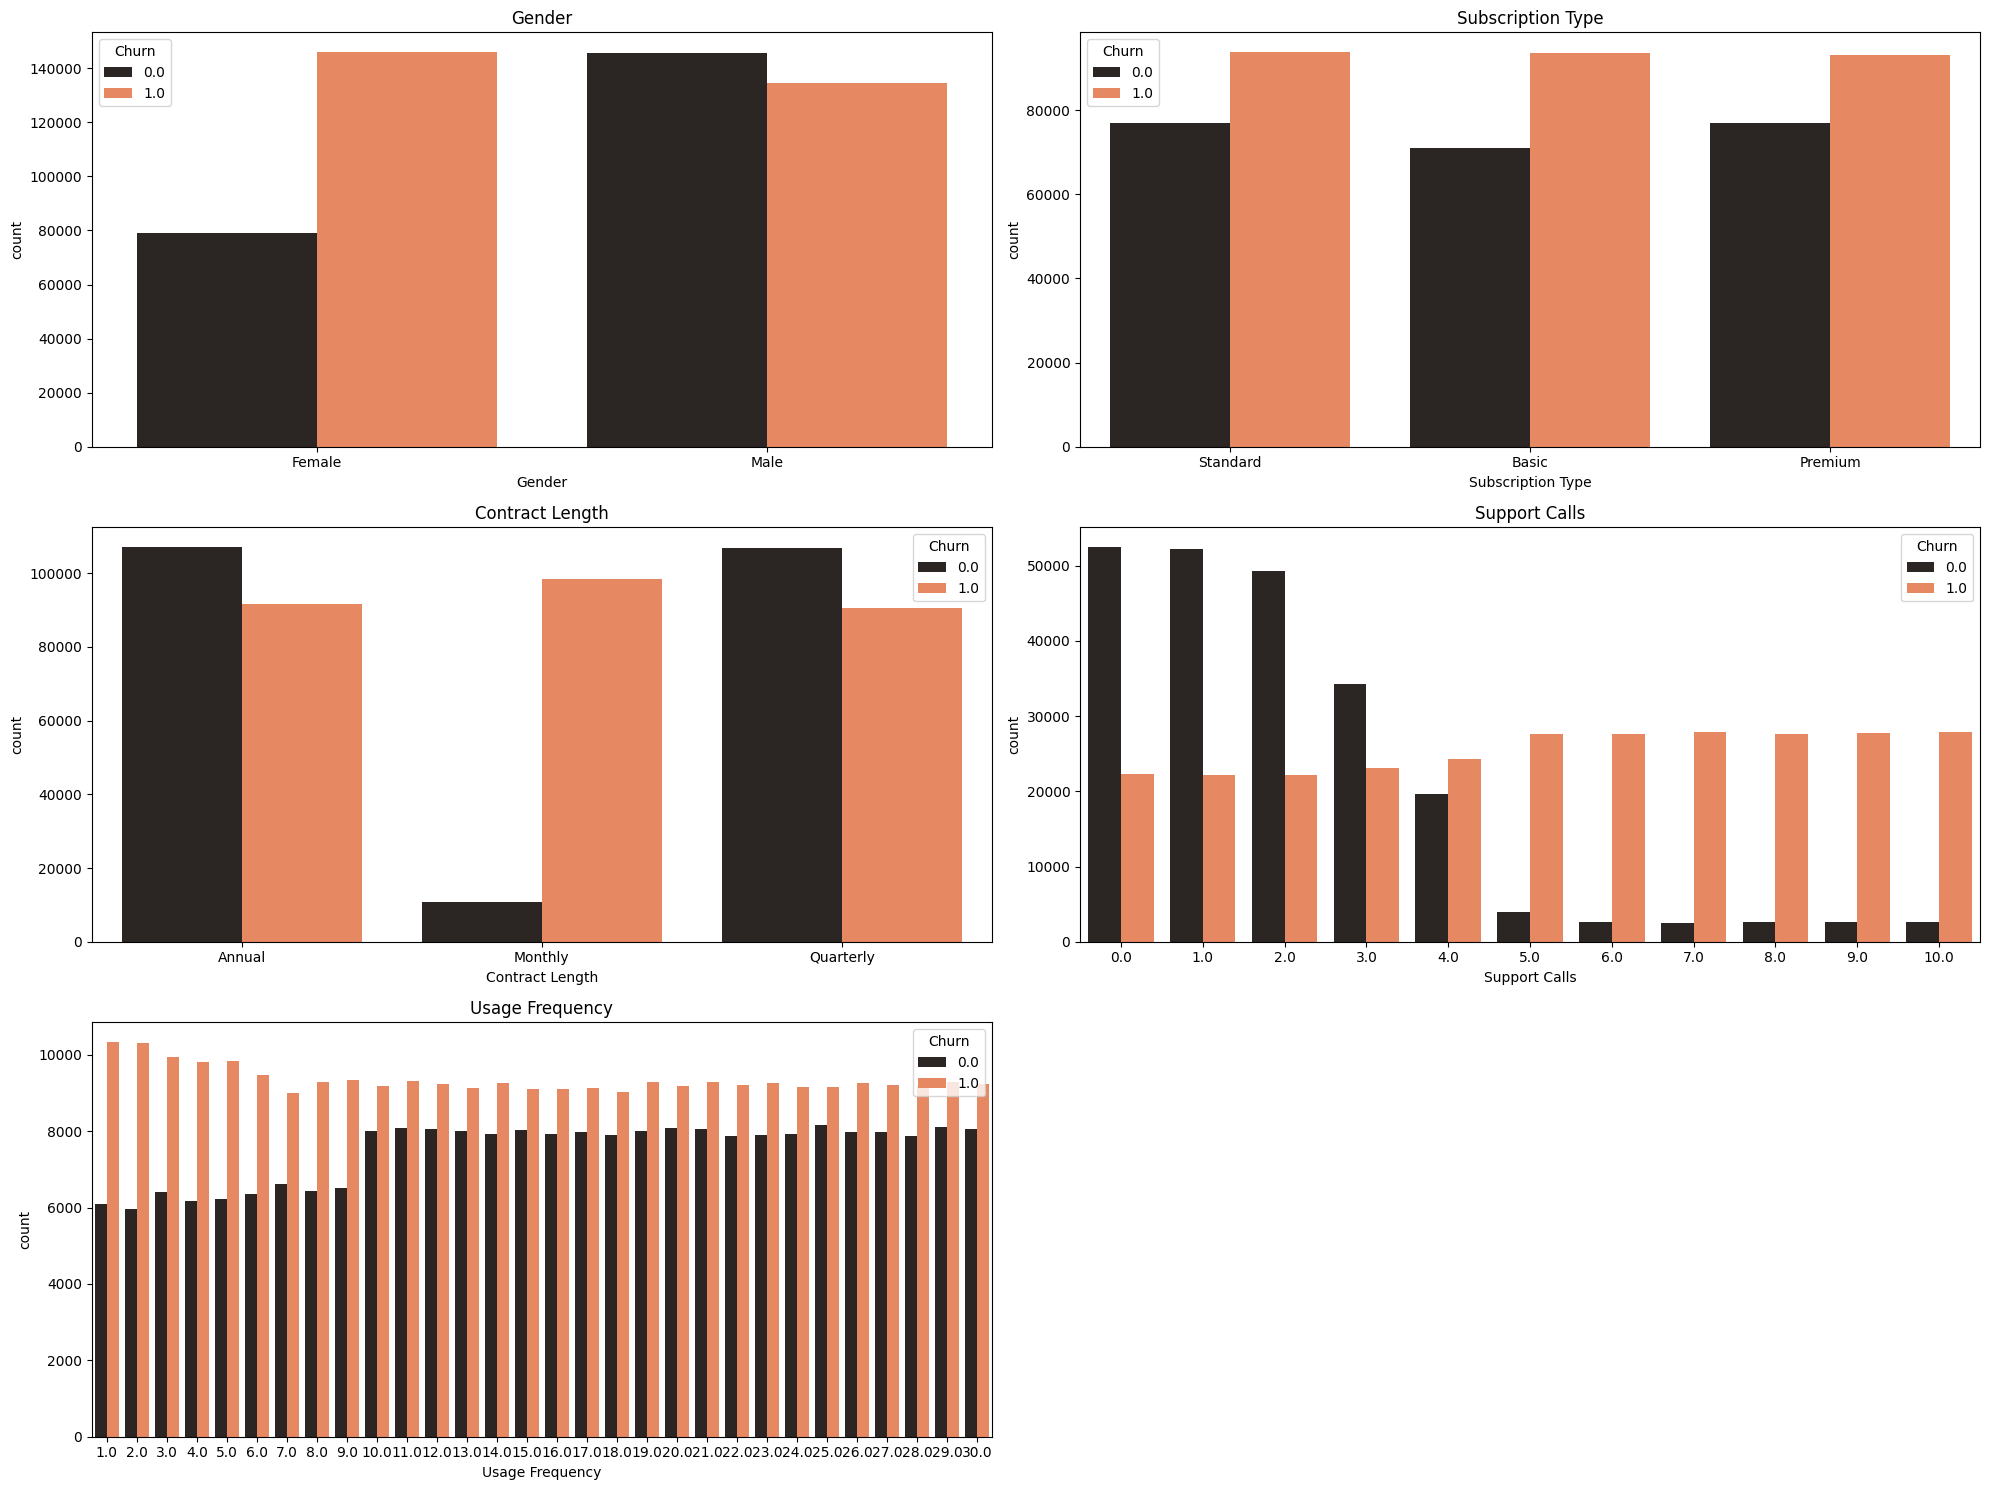

In [44]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length', 'Support Calls', 'Usage Frequency']

plt.figure(figsize= (20, 15))
for index, col in enumerate(cat_cols, 1):
    plt.subplot(3,2, index)
    sns.countplot(data= data, x= col, hue= 'Churn', color= (0.99, 0.5, 0.3))
    plt.title(col)
    
plt.tight_layout()
plt.show()

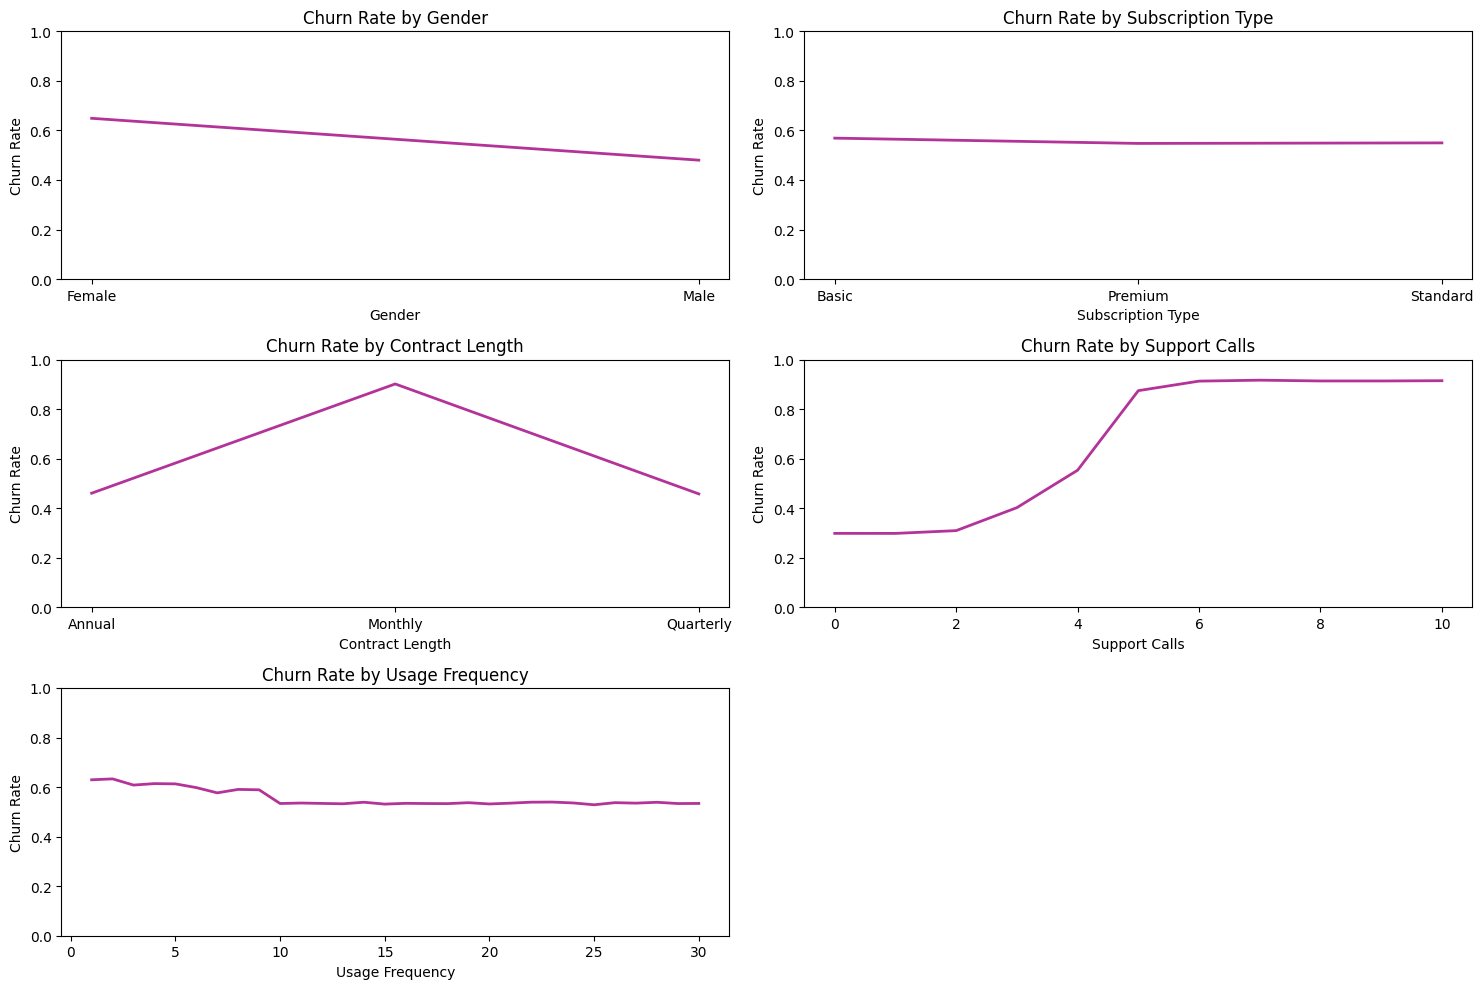

In [45]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length', 'Support Calls', 'Usage Frequency']

plt.figure(figsize=(15, 10))

for index, col in enumerate(cat_cols, 1):
    churn_rate = data.groupby(col)['Churn'].mean()
    
    plt.subplot(3, 2, index)
    plt.plot(churn_rate.index, churn_rate.values, color=(0.7, 0.2, 0.6), linewidth=2)
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Churn Rate')
    plt.ylim(0, 1)              # to reduce the zigzag in the line drawn (but change just the zoom of the plot)
    
plt.tight_layout()
plt.show()

**Categorical Features vs. Churn**

**Gender**
* Females show a higher number of churn cases compared to males.
* However, the total number of female customers is lower than males.
* This indicates a higher churn rate for females (~65%) compared to males (~45%).
* Gender acts as a strong demographic indicator.

**Contract Length**
* Churn counts appear similar across Monthly, Quarterly, and Annual contracts.
* Monthly contracts have the smallest base population and very low retention.
* This leads to a significantly higher churn rate (~75%) for Monthly plans.
* Longer contracts (Quarterly, Annual) show better retention behavior.

**Support Calls**
* Customers with 0–3 calls have high retention.
* At 4 calls, retention drops sharply.
* From 5–10 calls, churn approaches 100%.
* This suggests a strong behavioral threshold at around 3–4 calls.
* The extreme pattern also indicates possible synthetic behavior in the data.

**Subscription Type**
* Churn and retention distributions are nearly identical across all tiers.
* Churn rate stays almost constant (~55%) regardless of plan type.
* This feature provides no meaningful separation.
* Likely to have low importance in modeling.

**Usage Frequency**
* Churn consistently exceeds retention across all usage levels.
* Only minor variation in churn rate across the range.
* No clear separation between churned and retained users.
* Weak predictive signal.

**Key Takeaways**
* Churn rate (not raw counts) is essential for correct interpretation.
* Strong indicators:
  - Support Calls
  - Contract Length
  - Gender
* Weak indicators:
  - Subscription Type
  - Usage Frequency
* Strong features are expected to contribute more in modeling, while weak ones may have limited impact.

## 6. Correlation Analysis

<Axes: >

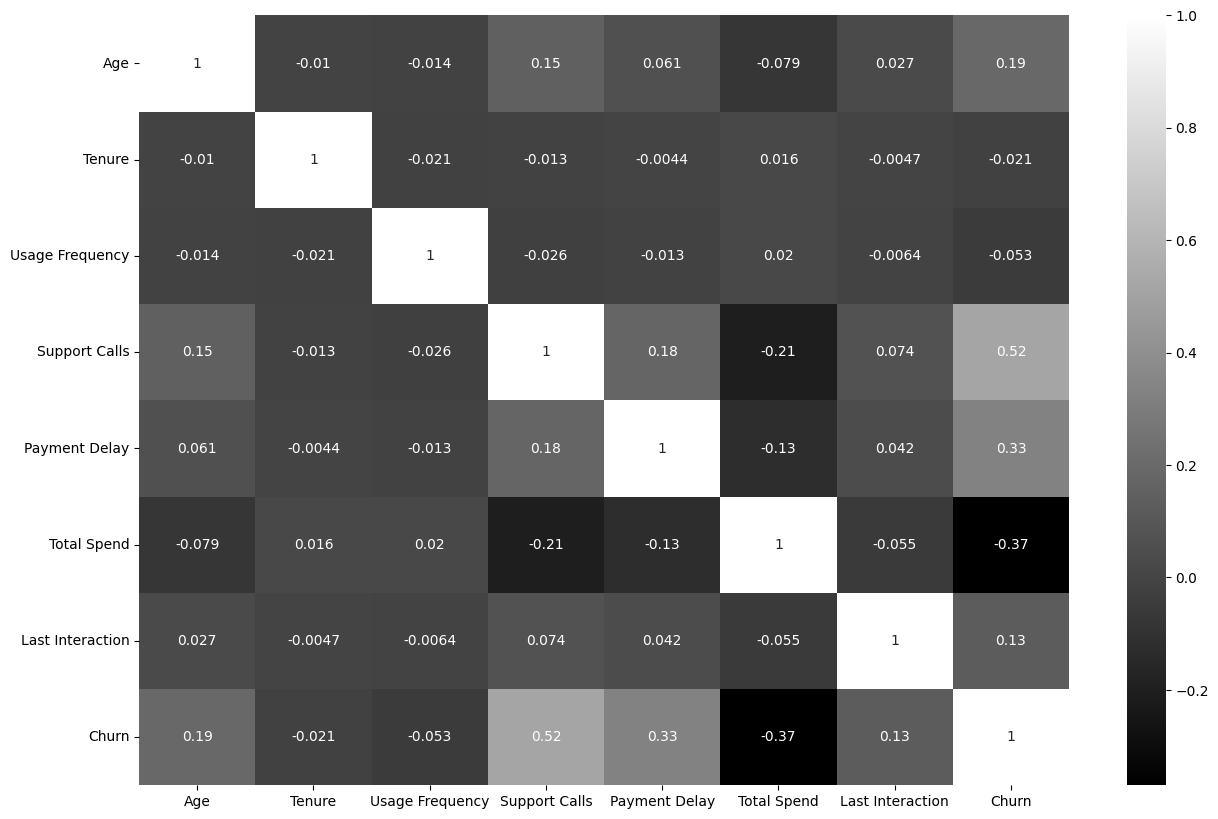

In [46]:
corr = data.select_dtypes('number').corr()

plt.figure(figsize= (15, 10))
sns.heatmap(corr, annot= True, cmap = 'gray')

**Correlation Analysis Insights**

* **Multicollinearity Check:** The heatmap reveals that the correlation coefficients between all independent numerical features are practically zero (ranging between -0.01 and 0.01). This indicates a complete absence of multicollinearity. The independent variables carry completely distinct information without overlapping, which is an ideal condition for training stable machine learning models.
* **Feature-Target Correlation:** The strongest correlations in the matrix exist exclusively between the features and the target variable (`Churn`), perfectly validating the behavioral thresholds identified in the bivariate analysis:
  * **Support Calls (0.52):** Exhibits the strongest positive linear relationship with churn, confirming it as the primary behavioral risk factor.
  * **Payment Delay (0.37):** Shows a moderate positive relationship, reinforcing that delayed payments are a strong indicator of impending churn.
  * **Total Spend (-0.37):** Exhibits a moderate negative relationship, mathematically confirming that higher monetary commitment is associated with customer retention.
* **Key Takeaway:** The dataset is structurally optimized for modeling. The independent features are non-redundant, and the most prominent linear indicators for predicting churn have been explicitly isolated.

---
---
---
---

# 7. Key Insights

## **Executive Summary: Key EDA Insights**

**1. Data Integrity and Quality**
The dataset is exceptionally clean. There are no missing values, and visual/statistical inspections confirm a complete absence of extreme numerical outliers or illogical data entries (e.g., negative ages). 

**2. Synthetic Data Characteristics**
Multiple indicators strongly suggest the dataset is synthetic or artificially balanced. These include highly uniform distributions across categorical variables (e.g., Usage Frequency, Subscription Type) and an unnatural overall churn rate exceeding 50%. While this eliminates the need for complex class-imbalance handling, insights should be interpreted within this synthetic context.

**3. Sharp Behavioral Thresholds**
Churn behavior in this dataset is not strictly linear; it is dictated by sharp, distinct thresholds. Customers generally maintain high retention until they hit specific limits, after which the churn probability spikes dramatically (e.g., Age > 50, Payment Delay > 20 days, Support Calls > 3).

**4. Absence of Multicollinearity**
The correlation matrix confirms that there is zero multicollinearity among the independent numerical features. Each feature provides unique variance. This is an optimal condition for training stable machine learning models, ensuring that feature weights will not be distorted by overlapping variables.

# 8. Feature Importance Hypothesis

## **Feature Importance & Engineering Strategy for Modeling**

**Expected Feature Importance (Based on EDA)**
Based on the bivariate analysis and correlation matrix, the features can be categorized by their anticipated predictive power:
* **High Importance:** `Support Calls` (highest positive correlation), `Payment Delay` (strong behavioral indicator), and `Contract Length` (massive churn rate in monthly contracts).
* **Moderate Importance:** `Age`, `Total Spend`, `Last Interaction`, and `Gender`. These features show distinct churn patterns but rely heavily on specific thresholds rather than general continuous trends.
* **Low/No Importance:** `Subscription Type`, `Usage Frequency`, and `Tenure`. These features exhibited nearly identical distributions across both churned and retained customers.

**Feature Engineering for Linear Models**
While tree-based models (like Random Forest or XGBoost) can natively capture the sharp cut-offs and non-linear relationships observed in the EDA, linear models (such as Logistic Regression) cannot. Linear models assume a constant rate of change, which contradicts the step-wise behavior seen in our data. To maximize the performance of linear models, we will engineer the following explicit binary and interaction features to capture these thresholds:

* **`Critical_Support_Calls` (Binary):** 1 if `Support Calls` > 3, else 0. (Captures the 100% churn rate observed after 4 calls).
* **`Severe_Payment_Delay` (Binary):** 1 if `Payment Delay` > 20, else 0. (Captures the sudden spike in churn for late payers).
* **`High_Risk_Age` (Binary):** 1 if `Age` > 50, else 0. (Highlights the specific demographic drop-off).
* **`Low_Spend_Flag` (Binary):** 1 if `Total Spend` < 500, else 0. (Separates the high-churn, low-spend tier from the stable, high-spend tier).
* **`Avg_Monthly_Spend` (Continuous Interaction):** `Total Spend` / `Tenure`. (Provides a normalized spending metric to better evaluate customer value over time).

# 9. Save The Data

In [ ]:
data.to_csv('../data/cleaned/cleaned_data.csv', index= False)